In [1]:
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"

import sys

sys.path.insert(0, "../..")

In [2]:
import chex
import dill
import jax
import jax.numpy as jnp
import json
import numpy as np
import pandas as pd

from flax import nnx
from torch.utils.data import DataLoader

from src.dataset import get_iter
from src.datasets.linear_regression import ICLinearRegression
from src.utils import parse_dict

In [3]:
def evaluate(learner_path):
    config_dict = json.load(open(os.path.join(learner_path, "config.json"), "r"))

    # Load model
    last_step = sorted(os.listdir(os.path.join(learner_path, "models")))[-1]
    train_state = dill.load(
        open(os.path.join(learner_path, "models", last_step), "rb")
    )
    model = nnx.merge(
        train_state.graphdef,
        train_state.params,
        train_state.rest,
    )

    half_precision = config_dict["half_precision"]
    eval_seed = 42
    batch_size = 32

    dtype = jnp.bfloat16 if half_precision else jnp.float32

    rng = jax.random.PRNGKey(eval_seed)
    rng, _ = jax.random.split(rng)

    # Get dataset
    dataset_kwargs = parse_dict(config_dict["dataset_kwargs"])
    dataset = ICLinearRegression(
        dataset_kwargs.num_tasks,
        dataset_kwargs.num_dims,
        dataset_kwargs.context_len,
        eval_seed,
        dataset_kwargs.train,
        dataset_kwargs.input_noise_std,
        dataset_kwargs.label_noise_std,
    )
    data_loader = DataLoader(
        dataset,
        batch_size=batch_size,
        num_workers=0,
    )
    data_iter = get_iter(data_loader, None, dtype)

    # Sample next batch and evaluate
    batch = next(data_iter)
    res = model(batch)
    errors = (batch["target"] - res) ** 2

    return errors

In [4]:
base_path = "/home/bryanpu1/projects/iclr_2026/icl_architecture/scaling_jax/results"

runs = (
    (
        "regression_gpt",
        "full_precision-06-10-25_12_41_06-91cd9916-d39a-4187-9875-772743724dce",
    ),
    (
        "regression_gru",
        "full_precision-06-10-25_12_41_08-dd688574-f529-4083-8bdf-dcd35d1daddd",
    ),
)

stats = []
for (algo_name, run_name) in runs:
    learner_path = os.path.join(base_path, algo_name, run_name)
    learner_errors = evaluate(learner_path)
    stats.append(dict(
        algo_name=algo_name,
        run_name=run_name,
        mean_error=np.mean(learner_errors, axis=0),
        std_error=np.std(learner_errors, axis=0),
    ))

df = pd.DataFrame(stats)

In [6]:
df

,algo_name,run_name,mean_error,std_error
0,regression_gpt,full_precision-06-10-25_12_41_06-91cd9916-d39a...,"[[0.92301977], [1.1011014], [0.5052634], [0.16...","[[0.9544826], [1.5331061], [0.60220987], [0.27..."
1,regression_gru,full_precision-06-10-25_12_41_08-dd688574-f529...,"[[0.9265129], [1.0645896], [0.49845764], [0.16...","[[0.94533175], [1.4869306], [0.60164636], [0.3..."


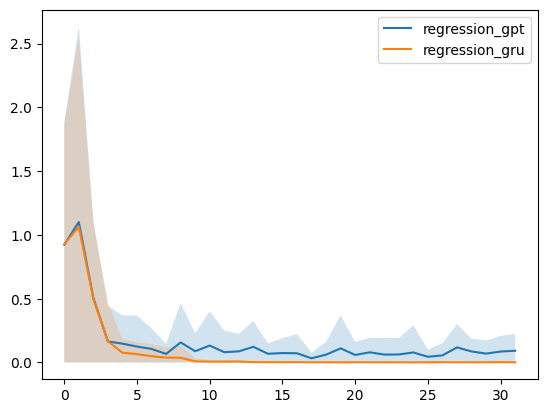

In [9]:
import matplotlib.pyplot as plt

for (row_i, row_data) in df.iterrows():
    mean_err = row_data["mean_error"].flatten()
    std_err = row_data["std_error"].flatten()
    context_len = len(mean_err)
    x_range = range(context_len)

    plt.plot(
        x_range,
        mean_err,
        label=row_data["algo_name"],
    )
    plt.fill_between(
        x_range,
        mean_err + std_err,
        np.clip(mean_err - std_err, a_min=0.0, a_max=np.inf),
        alpha=0.2,
    )

plt.legend()    